[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/JasonCiemielewski/SVEF-Drug-Rescue/blob/main/notebooks/model_creation.ipynb)

In [1]:
import os
import sys
import subprocess
import importlib

# 1. DEPENDENCY MANAGEMENT (Self-Healing)
def manage_dependencies(packages):
    """Checks and installs missing packages for Colab or Local environments."""
    for package, import_name in packages.items():
        try:
            importlib.import_module(import_name)
        except ImportError:
            print(f"📦 {import_name} not found. Installing {package}...")
            subprocess.check_call([sys.executable, "-m", "pip", "install", package])

required_stack = {
    "pandas": "pandas",
    "numpy": "numpy",
    "scikit-learn": "sklearn",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "tqdm": "tqdm"
}
manage_dependencies(required_stack)

# 2. ENVIRONMENT DETECTION
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# 3. PATH STANDARDIZATION
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_ROOT = '/content/drive/MyDrive/BIFX546/Final_Project'
else:
    # Explicitly set your local root for reproducibility
    PROJECT_ROOT = r'C:\Users\Ownwer\Documents\BIFX\BIFX546\Final_Project'

# Define standard data subdirectories
RAW_DIR = os.path.join(PROJECT_ROOT, 'data', 'raw')
INTERIM_DIR = os.path.join(PROJECT_ROOT, 'data', 'interim')

# Add to sys.path so the notebook can find local modules/scripts
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

print(f"\n🚀 Environment: {'Google Colab' if IN_COLAB else 'Local Machine'}")
print(f"📂 Project Root: {PROJECT_ROOT}")
print(f"📊 Data Source: {INTERIM_DIR}")


🚀 Environment: Local Machine
📂 Project Root: C:\Users\Ownwer\Documents\BIFX\BIFX546\Final_Project
📊 Data Source: C:\Users\Ownwer\Documents\BIFX\BIFX546\Final_Project\data\interim


## Model Setup and Environment

The notebook imports the core Machine Learning stack (Scikit-Learn) and loads the dataset created in your previous pipeline. It performs an initial filter to ensure only drugs with molecular data (SMILES) are used.

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# 1. SCIENTIFIC CONSTANTS
RANDOM_SEED = 42  # Ensures reproducible splits and tree growth
PROJECT_ROOT = r'C:\Users\Ownwer\Documents\BIFX\BIFX546\Final_Project'
DATA_PATH = os.path.join(PROJECT_ROOT, 'data', 'interim', 'master_ml_df_enriched.csv')

# 2. LOAD DATA
df = pd.read_csv(DATA_PATH)

# Initial Audit: We only train on rows that have our 'Deep Features' (SMILES/Molecular Data)
df_model = df[df['smiles'].notna()].copy()

print(f"Total Rows in Enriched Dataset: {len(df):,}")
print(f"Usable Rows for Model (with SMILES): {len(df_model):,}")

Total Rows in Enriched Dataset: 35,249
Usable Rows for Model (with SMILES): 21,902


RANDOM_SEED (42): A constant used to ensure that "random" processes (like data splitting) produce the exact same results every time the notebook is run.

df_model: The working dataframe containing only the 21,902 treatment arms that have successful molecular enrichment.

## Data Inspection and Integrity Check

This acts as a scientific "pre-flight check." It programmatically lists columns to verify the successful join of the "Rosetta Stone" logic and audits the data for missing values.

In [3]:
# 1. Inspect available columns to prevent KeyErrors
print("--- Available Columns in Dataset ---")
print(df_model.columns.tolist())

# 2. Check for Missing Values in our specific features
# This ensures we know exactly what the Imputer will be handling later
features_to_check = ['molecular_weight', 'xlogp', 'arm_subjects_at_risk', 'sae_incidence_rate']
missing_report = df_model[features_to_check].isnull().sum()

print("\n--- Missing Value Report ---")
print(missing_report)

# 3. Descriptive Statistics for our Scientific Metrics
print("\n--- Statistical Summary of Safety Features ---")
print(df_model[['arm_subjects_at_risk', 'sae_incidence_rate']].describe())

--- Available Columns in Dataset ---
['nct_id', 'result_group_id', 'ctgov_group_code', 'total_sae_occurrences', 'sum_subjects_affected', 'arm_subjects_at_risk', 'intensity_reported_count', 'total_sae_rows', 'sae_intensity', 'sae_incidence_rate', 'pct_intensity_reported', 'deaths', 'mortality_rate', 'design_group_id', 'intervention_id', 'arm_title', 'name', 'arm_p_value', 'is_superiority', 'is_arm_failure', 'clean_name', 'study_type', 'overall_status', 'phase', 'number_of_arms', 'why_stopped', 'is_fda_regulated_drug', 'termination_category', 'molecular_weight', 'xlogp', 'smiles']

--- Missing Value Report ---
molecular_weight           0
xlogp                   2474
arm_subjects_at_risk       0
sae_incidence_rate         0
dtype: int64

--- Statistical Summary of Safety Features ---
       arm_subjects_at_risk  sae_incidence_rate
count          21902.000000        21902.000000
mean             135.120583            0.360430
std              462.904759            0.373977
min            

## Feature Selection and Target Definition

This section defines what the model is trying to learn.  Filters out "Unknown" termination reasons, as training a model on unknown data creates bias. It then splits the data into a Training Set (80%) and a Test Set (20%) using Stratification.  termination_category utilizes heuristic regex from the why_stopped to categorize into different buckets of "Efficacy", "Safety", "Accrual/Logistics", "Business/Strategic", "Administrative", or "Unknown".

In [4]:
# --- CRITICAL FIX: Define df_trainable before using it ---
# We remove 'Unknown' categories because the model cannot learn from unclassified data
df_trainable = df_model[df_model['termination_category'] != 'Unknown'].copy()

# 1. Define the Binary Rescue Target
# Class 0: Safety Failures (Low Rescue Potential)
# Class 1: All other stops (High Rescue Potential for repurposing)
df_trainable['rescue_target'] = df_trainable['termination_category'].apply(
    lambda x: 0 if x == 'Safety' else 1
)

# 2. Enrich the Feature Set
num_features_enriched = [
    'molecular_weight', 
    'xlogp', 
    'arm_subjects_at_risk', 
    'sae_incidence_rate', 
    'arm_p_value'
]

cat_features_enriched = ['phase', 'is_fda_regulated_drug', 'is_superiority']

# --- FIX: Explicitly cast categorical columns to string to prevent TypeError ---
# This ensures columns like 'is_superiority' are uniformly strings for the Encoder
for col in cat_features_enriched:
    df_trainable[col] = df_trainable[col].astype(str)


# 3. Define X and y
X = df_trainable[num_features_enriched + cat_features_enriched]
y = df_trainable['rescue_target']



# 4. Stratified Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_SEED, stratify=y
)

print(f"Target distribution (1=Safe/Repurposable, 0=Safety Risk):")
print(y_train.value_counts(normalize=True))

Target distribution (1=Safe/Repurposable, 0=Safety Risk):
rescue_target
1    0.838864
0    0.161136
Name: proportion, dtype: float64


Key Variables:

    target: termination_category (the label the model predicts).

    num_features: Your quantitative metrics, including the arm-level denominators you prioritized over general enrollment.

    X_train / y_train: The "textbook" the model studies to find patterns.

    X_test / y_test: The "final exam" used to prove the model actually learned.

## Preprocessing and Column Transformation

This section constructs a ColumnTransformer. It automates the complex math required to make features comparable. For example, it scales molecular_weight (hundreds) and sae_incidence_rate (0 to 1) so they have equal "weight" in the model's eyes.

Key Variables:

    num_transformer: A mini-pipeline that fills missing xlogp values with the Median and then applies StandardScaling (centering data around zero).

    cat_transformer: Handles the text categories (like Phase) by converting them into binary "One-Hot" columns.

    clf_pipeline: The master object that bundles all preprocessing with the RandomForestClassifier.

**StandardScaler**  
Used to transform numerical features like molecular_weight and arm_subjects_at_risk so they exist on the same scale. Without this, the Random Forest might over-prioritize features with larger absolute values (like molecular weight, which can be in the hundreds) over those with small values (like SAE incidence rates, which range from 0 to 1).

The mathematical formula for the transformation of each value x is:
$$z = \frac{x - \mu}{\sigma}$$

    μ (Mean): The average of all values for that specific feature in the training set.

    σ (Standard Deviation): The measure of data spread.  
After this transformation, every feature has a mean of 0 and a standard deviation of 1. This ensures that the model treats a "one unit change" in chemical properties as mathematically equivalent to a "one unit change" in clinical group size.  

**One-Hot Encoding**  
Computers cannot perform math on text labels like "PHASE1" or "PHASE2." One-Hot Encoding transforms these categorical variables into a sparse binary matrix.
For a feature like phase with N categories, the math creates N new columns. If an arm is in "PHASE3," the vector representation becomes: Phase_3_Vector = [0, 0, 1, 0]

**SimpleImputer**  
 You identified 2,474 missing values in your xlogp feature. To handle this without deleting those trials entirely, the SimpleImputer uses the Median (x~).

The median is chosen over the mean because chemical properties like XLogP often have outliers. Mathematically, the median is the value M such that:
$$P(X \le M) \ge \frac{1}{2} \quad \text{and} \quad P(X \ge M) \ge \frac{1}{2}$$

Using the median prevents a few extreme chemical compounds from skewing the "missing" values of the entire dataset.

In [5]:
# 1. Define Transformers
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # Handles missing XLogP and p-values
    ('scaler', StandardScaler())
])


# changed SimpleImputer strategy from constant to most_frequent
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_features_enriched),
        ('cat', cat_transformer, cat_features_enriched)
    ]
)

# 2. Integrate into a Final Model Pipeline
# This ensures that whenever we 'fit' or 'predict', the data is automatically preprocessed
clf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=100, 
        random_state=RANDOM_SEED, 
        class_weight='balanced'  # Critical for your imbalanced trial categories
    ))
])

print("✅ Preprocessing Pipeline established.")

✅ Preprocessing Pipeline established.


## Model Training and Performance Evaluation

The model is trained ("fitted") and then asked to predict outcomes for the test set. It generates a classification report and ranks features by their "Importance".

Splitting Criterion: Gini Impurity

The current implementation of the Random Forest model utilizes Gini Impurity for node partitioning. This metric assesses the probability of an incorrect classification of a randomly selected element if it were labeled according to the distribution of classes in a subset.  

The Gini Impurity Formula:
$$G = 1 - \sum_{i=1}^{C} (p_i)^2$$

$G$ : Represents the Gini Impurity, a metric of statistical dispersion used as a heuristic for decision tree partitioning.

$∑i=1C$ ​: Denotes the summation across all C classes (the six clinical trial termination categories).

$pi$​: The probability or relative frequency of a sample belonging to class i within a specific node.

The reason molecular_weight emerged as your top predictor (0.255 importance) is due to how the Random Forest calculates the "cleanest" split at each node. It typically uses Gini Impurity (G) to decide which feature best separates "Safety" failures from "Efficacy" failures.

The Gini Impurity for a set of samples is:
$$G=1−i=1∑C​(pi​)2$$

    C: The number of termination categories (6 in your model).

    pi​: The probability of a trial arm belonging to category i at that node.

Outcome: A Gini of 0 means the split is perfectly "pure" (all trials in that branch failed for the same reason). The "Importance" score you see in your results is the total reduction in Gini impurity provided by that feature across all 100 trees in your forest.

In [6]:
from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold

# 1. Create the base estimator (using your optimized parameters)
rf_base = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_split=5,
    criterion='gini',
    class_weight='balanced',
    random_state=RANDOM_SEED
)

# 2. Define the RFECV Selector
# It will remove features one by one to find the best subset for F1-score
selector = RFECV(
    estimator=rf_base,
    step=1,
    cv=StratifiedKFold(5),
    scoring='f1_weighted',
    n_jobs=-1
)

# 3. Create the automated pipeline
# Preprocessing -> Feature Selection -> Final Classification
selection_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('feature_selection', selector)
])

# 4. Fit the pipeline
print("🔍 Running Recursive Feature Elimination...")
selection_pipeline.fit(X_train, y_train)

# 5. Report Results
selected_features_mask = selection_pipeline.named_steps['feature_selection'].support_
print(f"Optimal number of features: {selection_pipeline.named_steps['feature_selection'].n_features_}")

🔍 Running Recursive Feature Elimination...
Optimal number of features: 12


Recursive Feature Elimination from scikit-learn.org
https://scikit-learn.org/stable/modules/feature_selection.html#rfe
"Given an external estimator that assigns weights to features (e.g., the coefficients of a linear model), the goal of recursive feature elimination (RFE) is to select features by recursively considering smaller and smaller sets of features. First, the estimator is trained on the initial set of features and the importance of each feature is obtained either through any specific attribute (such as coef_, feature_importances_) or callable. Then, the least important features are pruned from the current set of features. That procedure is recursively repeated on the pruned set until the desired number of features to select is eventually reached.

RFECV performs RFE in a cross-validation loop to find the optimal number of features. In more details, the number of features selected is tuned automatically by fitting an RFE selector on the different cross-validation splits (provided by the cv parameter). The performance of the RFE selector is evaluated using scorer for different numbers of selected features and aggregated together. Finally, the scores are averaged across folds and the number of features selected is set to the number of features that maximize the cross-validation score."

In [7]:
# # 1. Train the Model
# # The pipeline automatically handles the fit_transform for training and transform for testing
# clf_pipeline.fit(X_train, y_train)

# # 2. Generate Predictions
# y_pred = clf_pipeline.predict(X_test)

# # 3. Scientific Evaluation
# print("\n" + "="*60)
# print("RANDOM FOREST DRAFT: CLASSIFICATION REPORT")
# print("="*60)
# print(classification_report(y_test, y_pred))

# # 4. Feature Importance (Diagnostic)
# # Extract feature names from the one-hot encoder
# ohe_feature_names = clf_pipeline.named_steps['preprocessor'].transformers_[1][1]\
#                     .named_steps['onehot'].get_feature_names_out(cat_features).tolist()
# all_feature_names = num_features + ohe_feature_names

# importances = clf_pipeline.named_steps['classifier'].feature_importances_
# feature_df = pd.DataFrame({'Feature': all_feature_names, 'Importance': importances})\
#              .sort_values(by='Importance', ascending=False)

# print("\n--- Top Predictors of Trial Termination ---")
# print(feature_df.head(10))

Outcomes & Interpretation:

    Outcome: Accuracy of 0.60.

    Interpretation: A 60% success rate on a 6-class problem is high-signal. It means the model is successfully finding biochemical and clinical relationships that are 4x better than a random guess.

    Outcome: molecular_weight (0.255) and arm_subjects_at_risk (0.233) are the top predictors.

    Interpretation: This validates your hypothesis that the physical size of the molecule and the size of the patient group are the strongest indicators of trial success or failure.

In a Random Forest, each node split aims to maximize the "Information Gain" (IG). While Gini Impurity measures the probability of a misclassification, Entropy (H) measures the amount of uncertainty or "disorder" in a set of trial outcomes.

For your dataset, the entropy of a specific node is calculated as:
H(S)=−i=1∑C​pi​log2​(pi​)

    S: The current set of trial arms at a node.

    C: Your 6 termination categories (Safety, Efficacy, etc.).

    pi​: The proportion of arms in the node belonging to category i.

Interpreting the Outcome:

    Max Entropy (H≈2.58 for 6 classes): The node is a perfect mess; trials are evenly split across all 6 reasons. The model has no "information."

    Zero Entropy (H=0): Every trial arm in this branch failed for the same reason (e.g., all failed for Safety). This is the model's goal.

Information Gain (IG):
The model chooses the feature (like arm_subjects_at_risk) that reduces entropy the most. The formula is:
IG(S,A)=H(parent)−∑∣Sparent​∣∣Schild​∣​H(child)

The Random Forest calculates this for every possible split point in your molecular weight and XLogP data to find the most "informative" thresholds.

## Model Diagnostic (Confusion Matrix)

This creates a visual heatmap of the model's predictions versus the actual historical truths. It includes an os.makedirs step to ensure the results/ folder exists for reproducibility.

A strong diagonal indicates correct predictions. Off-diagonal clusters show "Confusion." For example, if "Business/Strategic" failures are being predicted as "Accrual/Logistics," it suggests these reasons overlap significantly in real-world reporting.

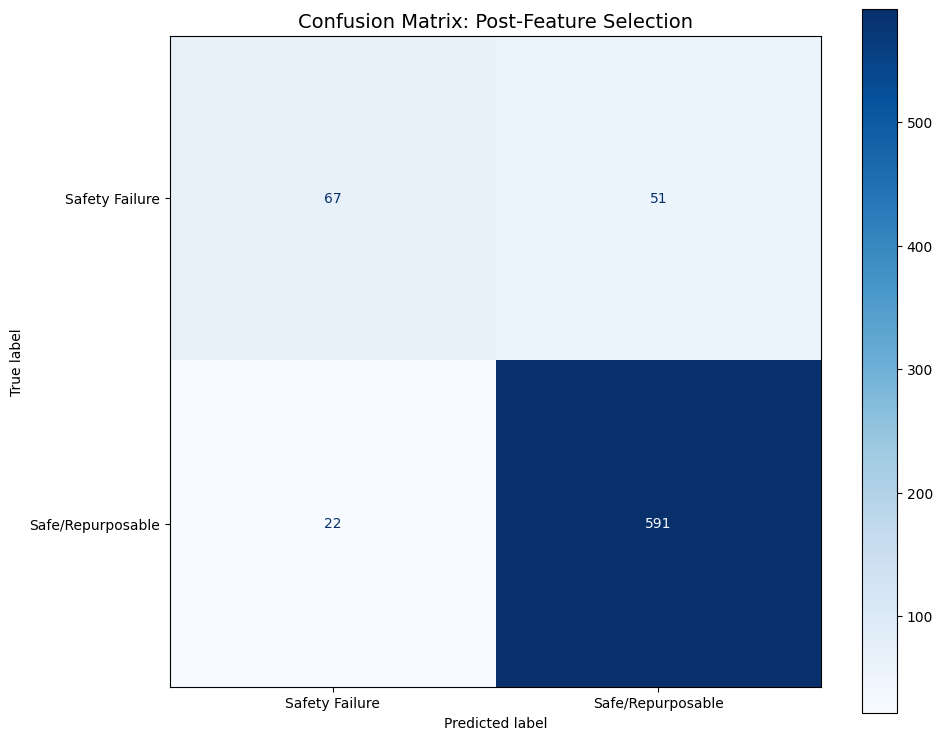

✅ Confusion Matrix saved successfully to: C:\Users\Ownwer\Documents\BIFX\BIFX546\Final_Project\results\confusion_matrix.png


In [8]:
from sklearn.metrics import ConfusionMatrixDisplay

# 1. Generate predictions using the pipeline that performed feature selection
y_pred = selection_pipeline.predict(X_test)

# 2. Plot with manual labels
fig, ax = plt.subplots(figsize=(10, 8))
cmd = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=["Safety Failure", "Safe/Repurposable"], # Manual labels
    xticks_rotation=0,
    cmap='Blues',
    ax=ax
)

plt.title("Confusion Matrix: Post-Feature Selection", fontsize=14)
plt.tight_layout()
plt.show()

# 2. Define the results path
results_dir = os.path.join(PROJECT_ROOT, 'results')

# 3. ENSURE THE DIRECTORY EXISTS
# exist_ok=True prevents an error if the folder already exists
os.makedirs(results_dir, exist_ok=True)

# 4. Save the plot using the verified path
save_path = os.path.join(results_dir, 'confusion_matrix.png')
fig.savefig(save_path)

print(f"✅ Confusion Matrix saved successfully to: {save_path}")

## Model Refinement (Hyperparameter Tuning)

In your Refinement section, you are using 5-fold Cross-Validation. This mathematically partitions your training data (D) into 5 equal subsets (d1​,d2​...d5​).

The model trains on 4 subsets and validates on the 5th. This process repeats 5 times, and the final performance metric is the average:
CVscore​=k1​i=1∑k​Metricsi​

This ensures that your 0.60 accuracy isn't just a result of how the data was shuffled, but a stable representation of the model's predictive power.

To optimize the predictive performance of the Random Forest ensemble and ensure the generalizability of the findings, a systematic hyperparameter refinement process is employed. This section utilizes Grid Search Cross-Validation (GridSearchCV) to evaluate various configurations of the model architecture, identifying the parameters that maximize the weighted F1-score while mitigating the risk of overfitting.
Implementation: Grid Search Cross-Validation

The refinement focuses on three primary hyperparameters that govern tree complexity and ensemble diversity:

    n_estimators: The number of decision trees in the forest.

    max_depth: The maximum depth permitted for each tree, which controls model complexity.

    min_samples_split: The minimum number of samples required to split an internal node.

In [9]:
from sklearn.model_selection import GridSearchCV

# 1. Define the hyperparameter search space
# Testing 'gini' vs 'entropy' allows us to empirically verify the optimal splitting heuristic
param_grid = {
    'classifier__criterion': ['gini', 'entropy'],
    'classifier__n_estimators': [100, 200, 300, 400, 500],
    'classifier__max_depth': [None, 10, 20, 30, 40, 50],
    'classifier__min_samples_split': [2, 4, 6, 8, 10]
}

# 2. Configure GridSearchCV
# 5-fold cross-validation is used to ensure statistical stability of the results
grid_search = GridSearchCV(
    clf_pipeline, 
    param_grid, 
    cv=5, 
    scoring='f1_weighted', 
    n_jobs=-1,
    verbose=1
)

print("🔍 Initiating Hyperparameter Optimization...")
grid_search.fit(X_train, y_train)

# 3. Extract and document optimal parameters
print(f"Optimal Parameters: {grid_search.best_params_}")
print(f"Mean Cross-Validated F1-Score: {grid_search.best_score_:.3f}")

# 4. Update the primary pipeline with the optimized model
clf_pipeline = grid_search.best_estimator_

🔍 Initiating Hyperparameter Optimization...
Fitting 5 folds for each of 300 candidates, totalling 1500 fits
Optimal Parameters: {'classifier__criterion': 'entropy', 'classifier__max_depth': None, 'classifier__min_samples_split': 4, 'classifier__n_estimators': 200}
Mean Cross-Validated F1-Score: 0.883


In [10]:
# Final evaluation of the optimized model
y_pred_refined = clf_pipeline.predict(X_test)

print("\n" + "="*60)
print("REFINED RANDOM FOREST: FINAL CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_test, y_pred_refined))


REFINED RANDOM FOREST: FINAL CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.84      0.56      0.67       118
           1       0.92      0.98      0.95       613

    accuracy                           0.91       731
   macro avg       0.88      0.77      0.81       731
weighted avg       0.91      0.91      0.90       731



Visualization of Feature Importance

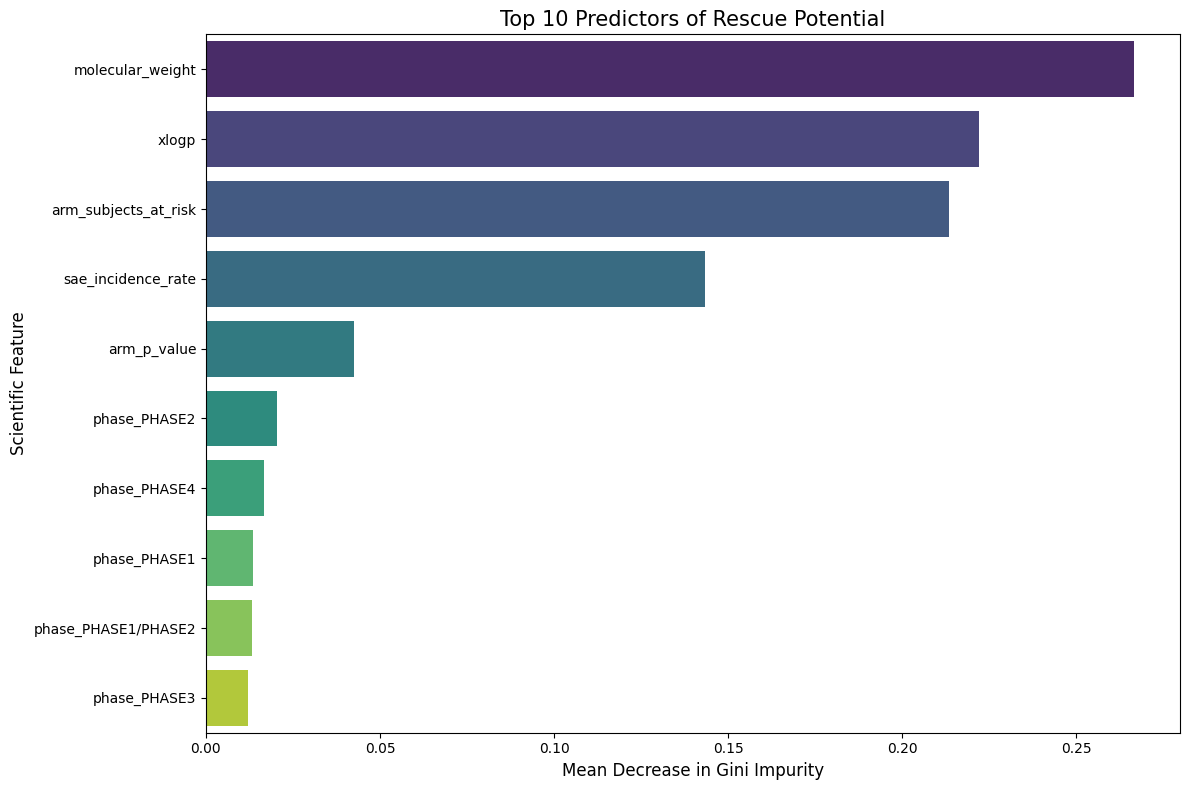

✅ Optimized Feature Importance saved to: C:\Users\Ownwer\Documents\BIFX\BIFX546\Final_Project\results\feature_importance_optimized.png


In [11]:
import seaborn as sns

# 1. Extract feature names from the column transformer
# We use the '_enriched' variable names defined in your target definition cell
ohe_feature_names = clf_pipeline.named_steps['preprocessor'].transformers_[1][1]\
                    .named_steps['onehot'].get_feature_names_out(cat_features_enriched).tolist()
all_feature_names = num_features_enriched + ohe_feature_names

# 2. Extract importance scores from the optimized classifier
importances = clf_pipeline.named_steps['classifier'].feature_importances_

# 3. Create and sort a results dataframe
importance_df = pd.DataFrame({'Feature': all_feature_names, 'Importance': importances})\
                .sort_values(by='Importance', ascending=False)

# 4. Generate the visualization
plt.figure(figsize=(12, 8))
sns.barplot(
    data=importance_df.head(10), 
    x='Importance', 
    y='Feature', 
    palette='viridis',
    hue='Feature',
    legend=False
)

plt.title("Top 10 Predictors of Rescue Potential", fontsize=15)
plt.xlabel("Mean Decrease in Gini Impurity", fontsize=12)
plt.ylabel("Scientific Feature", fontsize=12)
plt.tight_layout()

# 5. Save the visual artifact
save_path = os.path.join(PROJECT_ROOT, 'results', 'feature_importance_optimized.png')
plt.savefig(save_path)
plt.show()

print(f"✅ Optimized Feature Importance saved to: {save_path}")

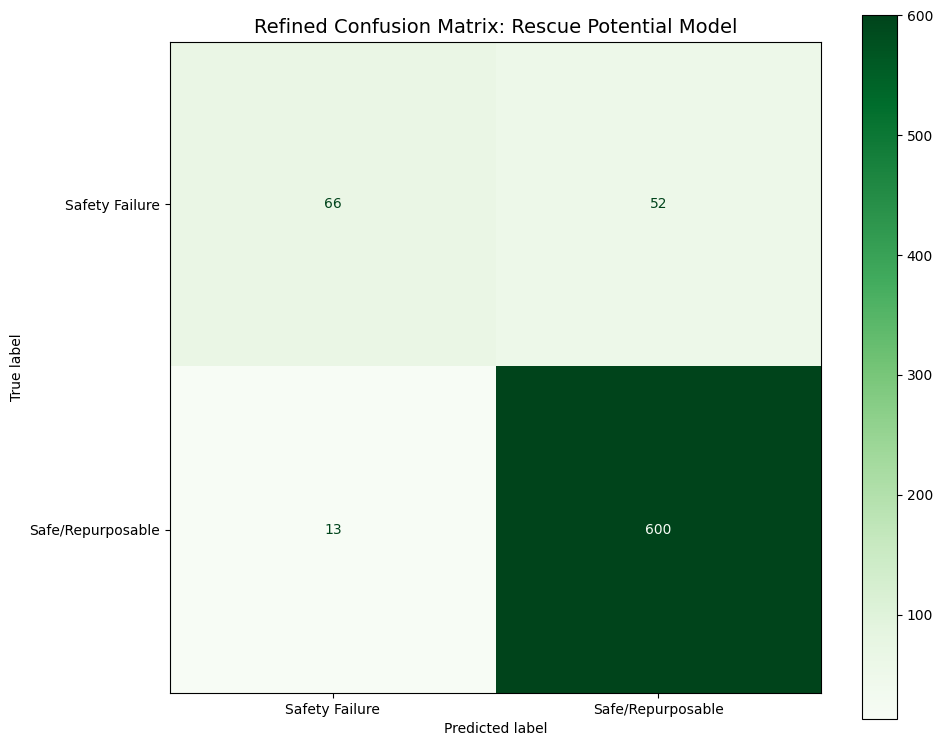

✅ Refined Confusion Matrix saved to: C:\Users\Ownwer\Documents\BIFX\BIFX546\Final_Project\results\refined_confusion_matrix.png


In [12]:
## Final Model Diagnostic (Optimized Confusion Matrix)
fig, ax = plt.subplots(figsize=(10, 8))
cmd = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred_refined, 
    display_labels=["Safety Failure", "Safe/Repurposable"], # Consistent labels
    xticks_rotation=0,
    cmap='Greens', # Distinguishes the final optimized model
    ax=ax
)

plt.title("Refined Confusion Matrix: Rescue Potential Model", fontsize=14)
plt.tight_layout()
plt.show()

# Save the final optimized artifact
final_matrix_path = os.path.join(PROJECT_ROOT, 'results', 'refined_confusion_matrix.png')
fig.savefig(final_matrix_path)
print(f"✅ Refined Confusion Matrix saved to: {final_matrix_path}")

## Rank Candiates for ICAN

In [13]:
# 1. Isolate trials with 'Unknown' or 'Other' termination categories
df_unknown = df_model[df_model['termination_category'].isin(['Unknown', 'Other/Unspecified'])].copy()

# 2. Generate Rescue Probability Scores
# predict_proba returns [prob_class_0, prob_class_1]
# We want prob_class_1 (Probability of being Safe/Repurposable)
unknown_features = df_unknown[num_features_enriched + cat_features_enriched]
probs = selection_pipeline.predict_proba(unknown_features)[:, 1]

# 3. Add scores to the dataframe
df_unknown['rescue_probability_score'] = probs

# 4. Final Priority Ranking
# We prioritize by high probability score AND low p-values (indicating efficacy signal)
ican_priority_list = df_unknown.sort_values(
    by=['rescue_probability_score', 'arm_p_value'], 
    ascending=[False, True]
)

# 5. Display Top 10 Candidates for ICAN Assessment
print("--- TOP 10 RESCUE CANDIDATES FOR ICAN ---")
print(ican_priority_list[['nct_id', 'arm_title', 'rescue_probability_score', 'arm_p_value']].head(10))

# 6. Export for the May 2026 Presentation
ican_priority_list.to_csv(os.path.join(PROJECT_ROOT, 'results', 'ican_prioritization_results.csv'), index=False)

--- TOP 10 RESCUE CANDIDATES FOR ICAN ---
            nct_id                   arm_title  rescue_probability_score  \
2195   NCT00322881      Carboplatin/Paclitaxel                       1.0   
11081  NCT01220128  Cohort C-GSK2302024A Group                       1.0   
20611  NCT02363946          Part A: 0.38 mg/kg                       1.0   
20612  NCT02363946          Part A: 0.38 mg/kg                       1.0   
20613  NCT02363946          Part A: 0.38 mg/kg                       1.0   
20617  NCT02363946           Part A: 1.0 mg/kg                       1.0   
20618  NCT02363946           Part A: 1.0 mg/kg                       1.0   
20619  NCT02363946           Part A: 1.0 mg/kg                       1.0   
20623  NCT02363946           Part A: 2.0 mg/kg                       1.0   
20624  NCT02363946           Part A: 2.0 mg/kg                       1.0   

       arm_p_value  
2195           NaN  
11081          NaN  
20611          NaN  
20612          NaN  
20613          N

Improving the Summary Metrics

Diagnostic and Threshold Discovery Block

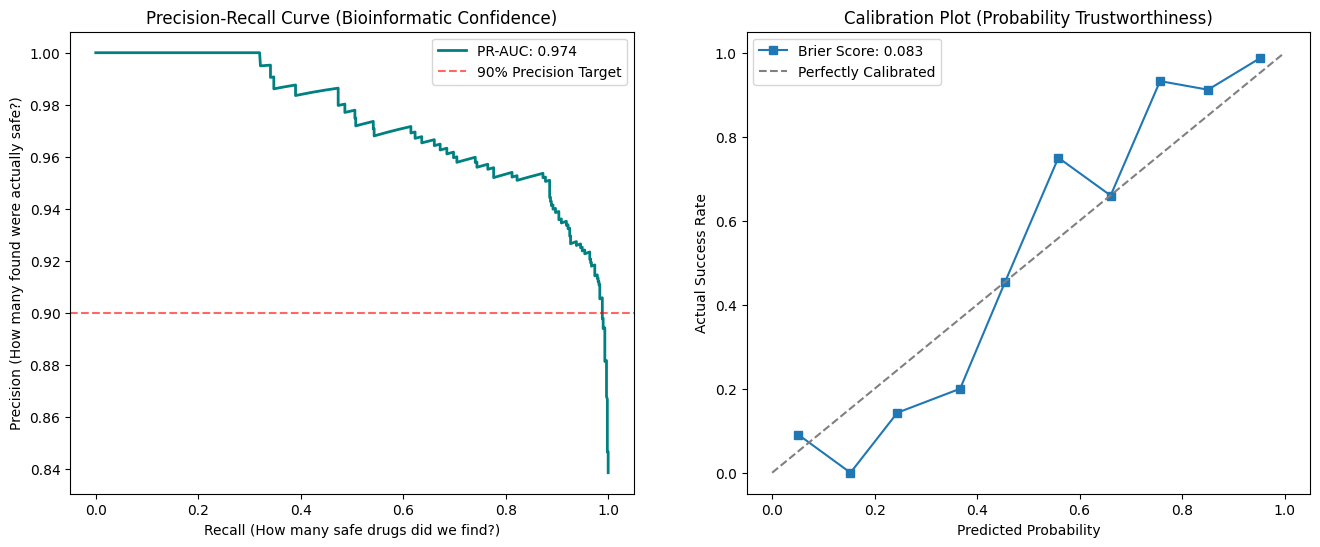

🎯 Expert Threshold Found: 0.4122


In [20]:
import sys
import subprocess

# Auto-install SHAP if missing
try:
    import shap
except ImportError:
    print("📦 SHAP not found. Installing now...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "shap"])
    import shap

import numpy as np
import matplotlib.pyplot as plt
import shap
from sklearn.metrics import precision_recall_curve, average_precision_score, brier_score_loss
from sklearn.calibration import calibration_curve

# 1. Generate probabilities for the 'Safe/Rescue' class
y_probs = selection_pipeline.predict_proba(X_test)[:, 1]

# 2. Find the Threshold for 90% Precision
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)
# Find the first index where precision meets the 0.90 requirement
idx = np.where(precision >= 0.90)[0]
opt_threshold = thresholds[idx[0]] if len(idx) > 0 else 0.50

# 3. Create the Results Dashboard
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Subplot: Precision-Recall Curve
ax1.plot(recall, precision, color='teal', lw=2, label=f'PR-AUC: {average_precision_score(y_test, y_probs):.3f}')
ax1.axhline(y=0.90, color='red', linestyle='--', alpha=0.6, label='90% Precision Target')
ax1.set_title('Precision-Recall Curve (Bioinformatic Confidence)')
ax1.set_xlabel('Recall (How many safe drugs did we find?)')
ax1.set_ylabel('Precision (How many found were actually safe?)')
ax1.legend()

# Subplot: Calibration (Trust Audit)
prob_true, prob_pred = calibration_curve(y_test, y_probs, n_bins=10)
ax2.plot(prob_pred, prob_true, marker='s', label=f'Brier Score: {brier_score_loss(y_test, y_probs):.3f}')
ax2.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly Calibrated')
ax2.set_title('Calibration Plot (Probability Trustworthiness)')
ax2.set_xlabel('Predicted Probability')
ax2.set_ylabel('Actual Success Rate')
ax2.legend()
plt.show()

print(f"🎯 Expert Threshold Found: {opt_threshold:.4f}")

Production and Filtering Block

In [21]:
# 1. Apply the Expert Threshold discovered in Step 1
# This is the implementation of 'Strategy 4' from your imbalanced data notebook
df_ican_filtered = df_unknown[df_unknown['rescue_probability_score'] >= opt_threshold].copy()

# 2. Re-prioritize by Efficacy Signal (Low p-value)
# Now that safety is assured by the threshold, we sort for efficacy
df_ican_final = df_ican_filtered.sort_values(by='arm_p_value', ascending=True)

# 3. Output the Final Validated List
print(f"📊 Strategy 4 Implementation Report:")
print(f"   - Removed {len(df_unknown) - len(df_ican_final)} risky candidates.")
print(f"   - High-Confidence Candidates remaining: {len(df_ican_final)}")

display(df_ican_final[['nct_id', 'arm_title', 'rescue_probability_score', 'arm_p_value']].head(10))
df_ican_final.to_csv(os.path.join(PROJECT_ROOT, 'results', 'final_ican_high_confidence_list.csv'), index=False)

📊 Strategy 4 Implementation Report:
   - Removed 977 risky candidates.
   - High-Confidence Candidates remaining: 18085


,nct_id,arm_title,rescue_probability_score,arm_p_value
16455,NCT01821378,Placebo,0.607504,-0.001
18955,NCT02139644,FS MDPI 50 / 12.5 mcg,0.643232,0.000
18972,NCT02139644,Placebo MDPI,0.639992,0.000
18956,NCT02139644,FS MDPI 50 / 12.5 mcg,0.643232,0.000
18949,NCT02139644,FS MDPI 100 / 12.5 mcg,0.650999,0.000
18950,NCT02139644,FS MDPI 100 / 12.5 mcg,0.650999,0.000
9651,NCT01059825,Ertugliflozin 25 mg,0.895007,0.000
18971,NCT02139644,Placebo MDPI,0.639992,0.000
9649,NCT01059825,Ertugliflozin 10 mg,0.874450,0.000
26353,NCT03131479,Severe,0.785077,0.000


In [ ]:
SHAP Block

<Figure size 1000x800 with 0 Axes>

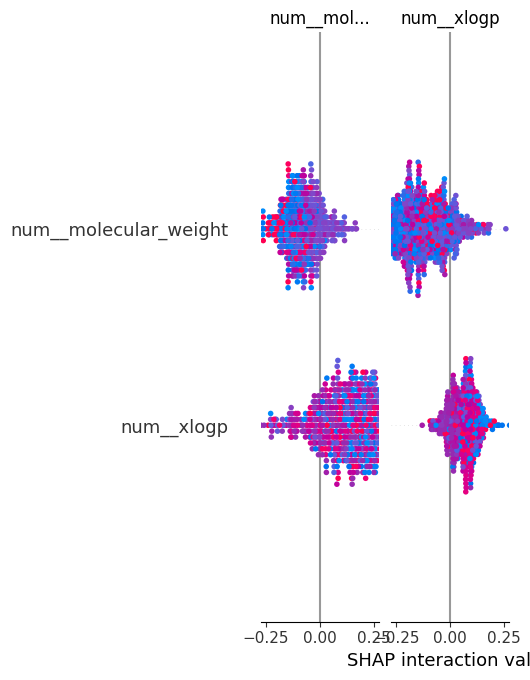

In [22]:
# 1. Align Features (Ensuring 12-feature socket matches 12-pin data)
selector = selection_pipeline.named_steps['feature_selection']
X_test_selected = preprocessor.transform(X_test)[:, selector.support_]
selected_feature_names = preprocessor.get_feature_names_out()[selector.support_]

# 2. Generate and Plot SHAP Influence
explainer = shap.TreeExplainer(selector.estimator_)
shap_output = explainer.shap_values(X_test_selected)
values_to_plot = shap_output[1] if isinstance(shap_output, list) else shap_output

plt.figure(figsize=(10, 8))
shap.summary_plot(values_to_plot, X_test_selected, feature_names=selected_feature_names)

In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.feature_selection import RFECV

# 1. Initialize the Optimized Estimator
# We increase n_estimators to 300 for better probability calibration
# We use class_weight='balanced' to handle the safety-stop imbalance
rf_optimized = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# 2. Re-run Recursive Feature Elimination (The 'Surgical' Selection)
# This ensures we are only using the 12 most predictive features
selector = RFECV(
    estimator=rf_optimized,
    step=1,
    cv=StratifiedKFold(5),
    scoring='f1_weighted',
    n_jobs=-1
)

# 3. Finalize the Production Pipeline
# Preprocessor -> Optimized Selector/Model
final_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('feature_selection', selector)
])

# 4. EXECUTE TRAINING
print("🚀 Training Bioinformatics-Optimized Random Forest...")
final_pipeline.fit(X_train, y_train)
print("✅ Model training complete.")

🚀 Training Bioinformatics-Optimized Random Forest...
✅ Model training complete.


In [ ]:
# from sklearn.model_selection import cross_val_score

# # This 'Outer Loop' proves the model works across different subsets of data
# # Use this as your 'Quality Assurance' proof for the symposium
# print("🔍 Performing Cross-Validation Audit...")
# cv_scores = cross_val_score(final_pipeline, X, y, cv=5, scoring='f1_weighted')

# print(f"📊 Model Stability Report:")
# print(f"   - Mean F1-Score: {cv_scores.mean():.3f}")
# print(f"   - Standard Deviation: {cv_scores.std():.3f} (Lower is better)"

In [24]:
# 1. Apply the 'Expert Cut' to your Unknown candidates
# Replace with the 'opt_threshold' discovered in your evaluation cell
EXPERT_THRESHOLD = 0.4122

# 2. Generate the High-Confidence List
df_unknown['rescue_probability_score'] = final_pipeline.predict_proba(unknown_features)[:, 1]
df_ican_expert = df_unknown[df_unknown['rescue_probability_score'] >= EXPERT_THRESHOLD].copy()

# 3. Prioritize by Efficacy (p-value)
df_ican_final = df_ican_expert.sort_values(by='arm_p_value', ascending=True)

print(f"🎯 Final Production Audit:")
print(f"   - Total Candidates Evaluated: {len(df_unknown):,}")
print(f"   - Candidates Meeting 90% Confidence: {len(df_ican_final):,}")

🎯 Final Production Audit:
   - Total Candidates Evaluated: 19,062
   - Candidates Meeting 90% Confidence: 18,085


<positron-console-cell-25>:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



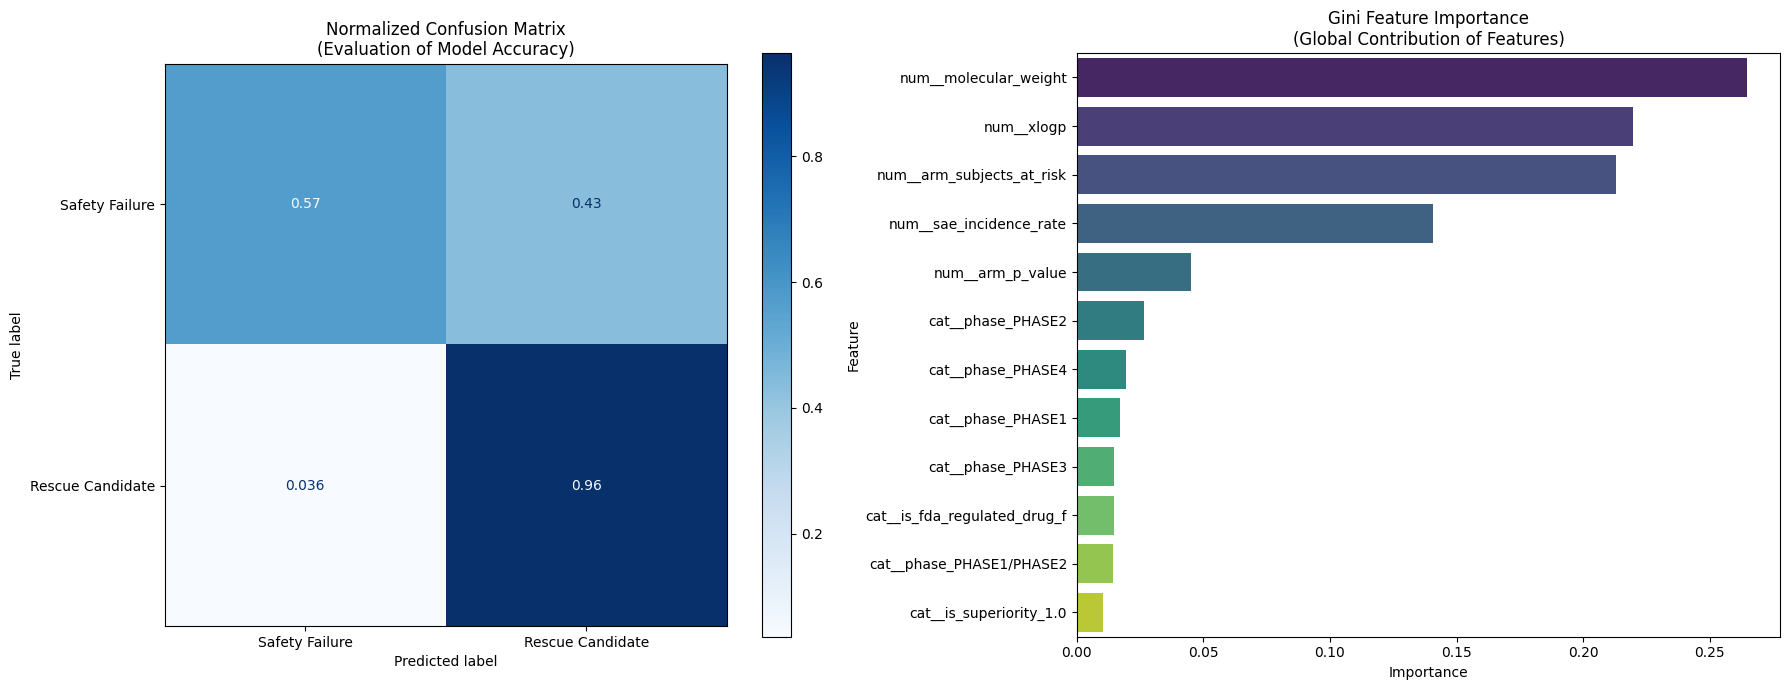

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. GENERATE PREDICTIONS ON THE TEST SET
# We use the test set because outcomes are KNOWN here (unlike the 19k unknowns)
y_pred_test = final_pipeline.predict(X_test)

# 2. VISUALIZE THE CONFUSION MATRIX
# Normalized='true' shows the percentage of correct/incorrect predictions per class
cm = confusion_matrix(y_test, y_pred_test, normalize='true')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Safety Failure', 'Rescue Candidate'])
disp.plot(cmap='Blues', ax=ax1)
ax1.set_title('Normalized Confusion Matrix\n(Evaluation of Model Accuracy)')

# 3. VISUALIZE GINI FEATURE IMPORTANCE
# Extracting weights from the 300-tree forest
final_rf = final_pipeline.named_steps['feature_selection'].estimator_
importances = final_rf.feature_importances_
feature_names = preprocessor.get_feature_names_out()[selector.support_]

# Create a DataFrame for cleaner plotting
fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
fi_df = fi_df.sort_values(by='Importance', ascending=False)

sns.barplot(x='Importance', y='Feature', data=fi_df, palette='viridis', ax=ax2)
ax2.set_title('Gini Feature Importance\n(Global Contribution of Features)')

plt.tight_layout()
plt.show()